# S04.4 – Time leakage: перемешали время и получили завышение метрик

Цель: увидеть, почему для временных данных случайный split опасен, и как делать честный split по времени.

## Что вы освоите
- Понять, что такое time leakage и почему он типичен для системных данных
- Сравнить случайный split vs split по времени
- Зафиксировать правила: train – прошлое, test – будущее

## Важные оговорки
- Мы создаём синтетический временной ряд, чтобы эффект был наглядным.
- Это не тема 'прогнозирования'. Это тема протокола валидации.

---


## Среда, воспроизводимость и стиль эксперимента

Перед кодом – несколько правил, которые будут повторяться во всех ноутбуках:

1) **Воспроизводимость**: фиксируем `random_state` / seed.  
2) **Разделение данных**: test‑часть – это *священная зона*. Мы смотрим на неё только в конце.  
3) **Всё, что "обучается" (`.fit`)** должно видеть только train‑данные (иначе легко получить утечки).  
4) **Sanity‑checks**: после каждого шага проверяем, что получился ожидаемый результат (формы, распределения, пересечения и т.д.).


In [1]:
# Импорты: минимальный, но достаточный набор
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Для красивых картинок (простая визуализация)
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)


numpy: 2.0.2
pandas: 2.2.2


## Общие функции (оценка моделей и печать метрик)

Чтобы не копировать одно и то же вручную, заведём пару функций.

Важно: эти функции *ничего не делают магически*. Мы специально пишем их максимально прозрачно,
чтобы вы видели, какие именно метрики считаются и на каких данных.


In [2]:
def summarize_binary_metrics(y_true, y_pred, *, positive_label=1):
    """Считает базовые метрики бинарной классификации.

    Мы считаем:
    - accuracy: доля верных ответов
    - precision: насколько "чистые" наши позитивные предсказания
    - recall: насколько хорошо мы находим позитивный класс
    - f1: гармоническое среднее precision и recall

    Почему это важно: в задачах безопасности цена FP и FN может быть разной.
    """
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
    }

def print_confusion(y_true, y_pred, labels=(0,1)):
    """Печать матрицы ошибок и пояснения, что есть что."""
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    df = pd.DataFrame(cm, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
    display(df)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN={tn} (верно: 0), FP={fp} (ложная тревога), FN={fn} (пропуск), TP={tp} (верно: 1)")
    return cm

def evaluate_model(model, X_train, y_train, X_test, y_test, *, model_name="model"):
    """Обучает модель на train и оценивает на test. Возвращает словарь метрик."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = summarize_binary_metrics(y_test, y_pred)
    print(f"=== {model_name} ===")
    print(metrics)
    print("Confusion matrix:")
    _ = print_confusion(y_test, y_pred)
    return metrics


## Идея: дрейф и причинная структура во времени

Во многих системах данные меняются:
- обновления ПО,
- смена конфигураций,
- новые типы атак,
- сезонность/нагрузка.

Если перемешать время случайно, модель "видит будущее" в train (в статистическом смысле),
и оценка становится завышенной.

Правильно: обучаемся на прошлом, тестируем на будущем.


In [3]:
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(RANDOM_STATE)
n = 5000
t = np.arange(n)

# Признак, который меняется со временем (дрейф)
x1 = np.sin(t / 50) + rng.normal(0, 0.2, size=n)

# Признак, который "включает" разные режимы после определённого момента
regime = (t > 3000).astype(int)
x2 = regime + rng.normal(0, 0.2, size=n)

# Метка зависит от режима и x1
y = ((0.8*x1 + 1.2*regime + rng.normal(0, 0.4, size=n)) > 0.5).astype(int)

X = pd.DataFrame({"x1": x1, "x2": x2, "t": t})
y = pd.Series(y, name="y")

print("Class balance:", y.value_counts(normalize=True).to_dict())


Class balance: {0: 0.5252, 1: 0.4748}


## Плохой протокол: случайный split (shuffle)

Здесь train и test перемешаны по времени.
Модель "подхватывает" статистику будущего режима в обучении.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["t"]), y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
bad = summarize_binary_metrics(y_test, y_pred)
print("BAD (random split) metrics:", bad)


BAD (random split) metrics: {'accuracy': 0.8328, 'precision': 0.8824701195219123, 'recall': 0.7470489038785835, 'f1': 0.8091324200913242}


## Хороший протокол: split по времени

Возьмём первые 75% времени как train, последние 25% как test.


In [5]:
cut = int(0.75 * n)
X_train2 = X.iloc[:cut].drop(columns=["t"])
y_train2 = y.iloc[:cut]
X_test2  = X.iloc[cut:].drop(columns=["t"])
y_test2  = y.iloc[cut:]

# sanity: train предшествует test
assert X.iloc[:cut]["t"].max() < X.iloc[cut:]["t"].min()

model2 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)
good = summarize_binary_metrics(y_test2, y_pred2)
print("GOOD (time split) metrics:", good)


GOOD (time split) metrics: {'accuracy': 0.8416, 'precision': 0.9369565217391305, 'recall': 0.8602794411177644, 'f1': 0.8969823100936525}


## Визуализация: как меняются признаки/режимы

Это нужно, чтобы "глаза поверили" в то, что данные реально менялись.


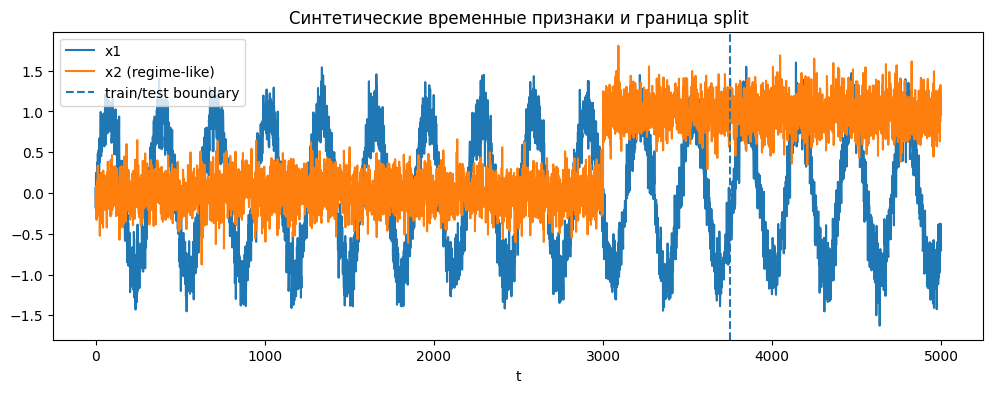

In [6]:
plt.figure(figsize=(12,4))
plt.plot(X["t"].values, X["x1"].values, label="x1")
plt.plot(X["t"].values, X["x2"].values, label="x2 (regime-like)")
plt.axvline(cut, linestyle="--", label="train/test boundary")
plt.xlabel("t")
plt.title("Синтетические временные признаки и граница split")
plt.legend()
plt.show()


## Финальный вывод + чеклист анти‑leakage (ядро)

Соберём чеклист, который можно переносить в S05/S06:

1) Test смотрим ровно 1 раз, в конце.  
2) Всё с `.fit` – только на train (Pipeline).  
3) Если есть группы (user/device/doc) – split по группам.  
4) Если есть время – train в прошлом, test в будущем (TimeSeriesSplit / holdout).  
5) Подозрительно высокие метрики – повод искать leakage, а не праздновать.  
6) Сравнение моделей – только на одном и том же протоколе и метриках.

Это и есть ваш DoD для S04: "хороший vs плохой протокол" воспроизведён и правила зафиксированы.


In [7]:
summary = pd.DataFrame([
    {"protocol": "BAD random split", **bad},
    {"protocol": "GOOD time split", **good},
]).set_index("protocol")
display(summary)


,accuracy,precision,recall,f1
protocol,,,,
BAD random split,0.8328,0.882470,0.747049,0.809132
GOOD time split,0.8416,0.936957,0.860279,0.896982
